# Small Models, Smart Graphs
### A three-part investigation of multi-hop reasoning on GRBench

**CSCE 676 · Data Mining & Analysis · Spring 2026**
**Yuyang Bai** · Texas A&M University · `ybai@tamu.edu`

Project repository: [github.com/leopoldwhite/CSCE676-Project](https://github.com/leopoldwhite/CSCE676-Project)

---

## Collaboration declaration

**1. Human collaborators.** None. This is an individual project; no teammates contributed.

**2. Web sources consulted.** The GRBench benchmark (Jin et al., ACL 2024 · [grbench](https://github.com/PeterGriffinJin/Graph-CoT)); scikit-learn, UMAP-learn, sentence-transformers, networkx, python-louvain, HuggingFace `transformers`, vLLM, and matplotlib documentation; ACL 2026 ARR January-cycle reviewer comments on the accompanying research paper; Nadeau & Bengio (2003) on the corrected-resampled t-test.

**3. AI tools used.** Anthropic Claude (Cowork) for Canvas extraction and narrative drafting; Anthropic Claude Code for running the RQ1/RQ2/RQ3 experiments locally and producing the `handoff/` artefacts this notebook curates. Every methodological decision in this notebook was made by the author — AI tools executed code, extracted numbers, and drafted prose, all under explicit direction. Outputs were verified cell-by-cell against the underlying CSV tables before inclusion.

**4. Citations.**
- Jin, B., et al. (2024). *Graph Chain-of-Thought: Augmenting Large Language Models by Reasoning on Graphs.* ACL 2024.
- Nadeau, C., & Bengio, Y. (2003). *Inference for the Generalization Error.* Machine Learning, 52, 239–281.
- Blondel, V. D., Guillaume, J. L., Lambiotte, R., & Lefebvre, E. (2008). *Fast unfolding of communities in large networks.* J. Stat. Mech.
- Reimers, N., & Gurevych, I. (2019). *Sentence-BERT: Sentence Embeddings using Siamese BERT-Networks.* EMNLP 2019.
- McInnes, L., Healy, J., & Melville, J. (2018). *UMAP: Uniform Manifold Approximation and Projection.* arXiv:1802.03426.
- Schulman, J., Wolski, F., Dhariwal, P., Radford, A., & Klimov, O. (2017). *Proximal Policy Optimization Algorithms.* arXiv:1707.06347.
- Qwen Team (2025). *Qwen2.5 Technical Report.* arXiv:2412.15115. (Qwen2.5-3B-Instruct backbone; Qwen3-8B / Qwen3-14B prompted baselines.)
- Lin, C.-Y. (2004). *ROUGE: A Package for Automatic Evaluation of Summaries.* Text Summarization Branches Out, ACL 2004 Workshop. (Primary generation-quality metric throughout RQ3.)
- Page, L., Brin, S., Motwani, R., & Winograd, T. (1999). *The PageRank Citation Ranking: Bringing Order to the Web.* Stanford InfoLab Technical Report. (Used in RQ2 keyword-graph centrality analysis.)
- MacQueen, J. (1967). *Some Methods for Classification and Analysis of Multivariate Observations.* Proc. 5th Berkeley Symposium on Mathematical Statistics and Probability. (K-Means clustering, used in RQ1.)

## Executive summary

Large language models are fluent readers and surprisingly weak graph reasoners. This project investigates — across 1,740 question-answer pairs drawn from ten domains in GRBench — whether smaller models can close that gap by learning to exploit the *structure* of the knowledge graphs they reason over. Three research questions organise the work:

1. **Content or label?** Text Mining + Clustering. *Finding:* replacing the coarse domain label with Sentence-BERT embeddings lifts macro-F1 on difficulty prediction from **0.33** to **0.83** (paired p < 10⁻⁴). Unsupervised clustering, however, recovers *topic* (ARI 0.26 vs. domain) rather than *difficulty* (ARI 0.04) — a finding that frames RQ2.
2. **Central or peripheral?** Graph Mining + Community Detection. *Finding:* keyword co-occurrence graphs differ sharply across domains (Legal is twice as large as the median domain), and graph centrality correlates **negatively and significantly** with difficulty (Spearman r = **−0.160**, p = 1.9 × 10⁻¹¹, n = 1,740). Harder questions pull on rarer, peripheral vocabulary — which explains why a simple TF-IDF baseline (**macro-F1 0.926**) unexpectedly beats dense embeddings on the same task.
3. **Teach, not scale?** Graph-aware reinforcement learning (external technique). *Finding:* a 3-billion-parameter model trained with a biased-mixture curriculum — concentrating training effort at the frontier of current competence — reaches Rouge-L **40.62** and GPT4Score **42.25** averaged over four held-out test domains, **matching** the prompted 14-billion baseline (39.85 / 42.01) and beating vanilla PPO-style RL by +2.13 / +3.20 on the same 3B backbone.

The arc is a course-length argument for *curriculum over scale* on structured-knowledge QA. The notebook is honest about the regressions (Literature-Hard drops 12.75 Rouge-L points under curriculum vs. vanilla) and about the single-seed training regime. The companion paper was submitted to ACL 2026 ARR January cycle, received an AC Findings recommendation, and was ultimately rejected on 2026-04-06 on novelty and seed-robustness grounds.

## 0. Setup

*Why this cell exists:* pinning the RNG, the handoff path, and the plotting defaults up-front makes every downstream result deterministic for the reader.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

np.random.seed(42)

# The handoff/ folder is produced by the experimental pipeline. This notebook curates it — it does not re-run the full experiments.
# See the project README for how to rebuild handoff/ from scratch.
HANDOFF = Path("../handoff").resolve()
RQ1 = HANDOFF / "rq1_text_clustering"
RQ2 = HANDOFF / "rq2_graph_mining"
RQ3 = HANDOFF / "rq3_graph_aware_rl"
assert HANDOFF.exists(), f"handoff/ not found at {HANDOFF}"

# Publication-quality defaults
mpl.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 180,
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

# Method-naming map: aligns CSV-stored labels with the public-facing display names used throughout this notebook.
METHOD_LABELS = {
    "Graph-CoT (prompting)": "Graph-CoT (prompting)",
    "Vanilla RL (PPO, uniform sampler)": "Vanilla RL (PPO)",
    "Curriculum RL (ours, biased-mixture)": "Curriculum RL (ours)",
    "Pure E2H (Gaussian only, ablation)": "Pure-E2H ablation",
    "Graph-CoT": "Graph-CoT",
    "Vanilla RL": "Vanilla RL",
    "Curriculum RL (ours)": "Curriculum RL (ours)",
    "Vanilla PPO": "Vanilla RL (PPO)",
    "Qwen2.5-3B (base)": "Qwen2.5-3B (base, no RL)",
}

# Shared colour scheme
PALETTE = {"prompt": "#4B6BBD", "vanilla": "#D98445", "ours": "#1F8A70", "base": "#8A8A8A"}


## 1. Motivation & research questions

Ask a 14-billion-parameter language model: *"Which co-authors of Dr. Smith published at ACL 2024?"* It will answer confidently — and usually incorrectly. The answer isn't in the question's text; it's in a graph of authors, papers, and venues. The model has to **traverse** a knowledge graph to find it, and current models mostly don't know how.

The GRBench benchmark (Jin et al., ACL 2024) quantifies this weakness by wrapping each question around a named knowledge graph (DBLP, MAG, Amazon, legal opinions, etc.) and grading model answers against the ground-truth sub-graph. Across 1,740 questions and ten domains, even strong proprietary models score below 45% Rouge-L on average, and below 10% on the Hard tier of many domains.

### Three research questions (frozen at Checkpoint 2)

Each RQ targets a different layer of the problem, and the three together satisfy the course requirement of ≥2 in-course techniques plus ≥1 external technique.

| # | Question | Technique | Category |
|---|----------|-----------|----------|
| RQ1 | Do text embeddings and unsupervised clustering reveal question-difficulty structure better than the domain label alone? | Sentence-BERT embeddings + K-Means / DBSCAN + classification | **Course technique** |
| RQ2 | What structural properties of keyword co-occurrence graphs differentiate domains, and do graph centrality measures correlate with question difficulty? | Keyword graphs + PageRank / betweenness + Louvain | **Course technique** |
| RQ3 | Can graph-aware reinforcement learning improve multi-hop reasoning trajectories on GRBench compared to prompting-only baselines? | PPO-style RL with a biased-mixture curriculum on Qwen2.5-3B-Instruct | **External technique** |

The design is intentional. RQ1 asks whether the question **content** carries signal that the coarse domain label misses. RQ2 sharpens the answer structurally — if hard questions use peripheral words, they probably require deeper graph traversal. RQ3 builds a model that *does* that traversal and tests whether it beats prompting-only baselines at matched cost.

## 2. Dataset — GRBench

GRBench is a graph-reasoning benchmark of 1,740 question-answer pairs. Each question is paired with a named knowledge graph its answer lives in. The ten domains span academic graphs (DBLP, MAG), commerce (Amazon), life sciences (biomedical), legal opinions, and a number of scientific sub-fields (physics, chemistry, materials science). Questions are labelled *easy*, *medium*, or *hard*.

### Why GRBench specifically?
- The **graph substrate** is explicit and evaluable. Unlike HotpotQA or LFQA, GRBench scores whether the retrieved sub-graph actually contains the answer, not merely whether the final text reads well.
- The scale is **semester-manageable**: 1,740 items lets all three RQs complete without heavyweight compute.
- It has an **established baseline suite** (Graph-CoT prompting with Qwen-family backbones), giving a clean comparison point for RQ3.

The high-level statistics below are re-loaded from the RQ1 artefact rather than recomputed on the raw data — the raw GRBench graphs are multi-gigabyte and live outside this workspace.

In [2]:
rq1_metrics = json.loads((RQ1 / "metrics.json").read_text())

# Dataset summary recovered from the RQ1 run.
n_questions = rq1_metrics["n_questions"]
level_counts = rq1_metrics["level_counts"]
domain_counts = rq1_metrics["domain_counts"]

print(f"Total questions: {n_questions}")
print(f"Domains: {len(domain_counts)}\n")
pd.Series(level_counts, name="n").to_frame().assign(share=lambda d: d["n"] / d["n"].sum()).round(3)


Total questions: 1740
Domains: 10



,n,share
medium,920,0.529
easy,700,0.402
hard,120,0.069


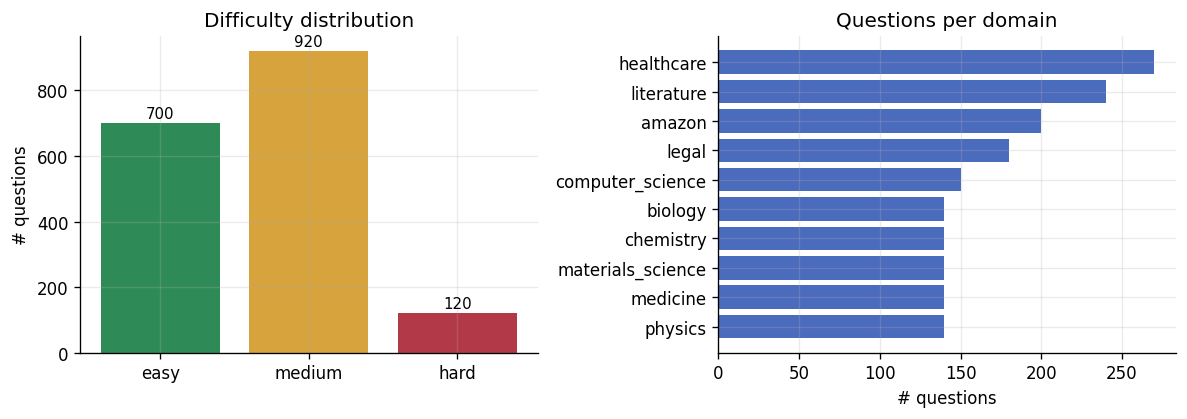

In [3]:
# Visual: class balance across difficulty, and distribution across domains.
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))

levels = ["easy", "medium", "hard"]
ax = axes[0]
ax.bar(levels, [level_counts[k] for k in levels], color=["#2E8B57", "#D6A33C", "#B23A48"])
ax.set_ylabel("# questions"); ax.set_title("Difficulty distribution")
for i, k in enumerate(levels):
    ax.text(i, level_counts[k] + 15, str(level_counts[k]), ha="center", fontsize=9)

ax = axes[1]
dom_sorted = dict(sorted(domain_counts.items(), key=lambda kv: kv[1], reverse=True))
ax.barh(list(dom_sorted.keys())[::-1], list(dom_sorted.values())[::-1], color="#4B6BBD")
ax.set_xlabel("# questions"); ax.set_title("Questions per domain")

plt.tight_layout(); plt.show()


Two observations worth stating up-front:

1. **Class imbalance is severe on the Hard tier.** Only ~120 of 1,740 questions are labelled hard, which means every Hard-split metric is noisier than the Easy counterpart. Throughout the notebook, I use **macro-F1** (unweighted average over classes) rather than accuracy, so Hard carries equal weight to the majority classes.
2. **Domain coverage is uneven.** Legal, literature, and healthcare are the largest — which becomes important in RQ2, where the Legal vocabulary graph is noticeably denser than any other domain's.


## 3. RQ1 — Content or label? *Text Mining + Clustering*

> *Can text embeddings and unsupervised clustering reveal latent question types that predict difficulty level better than domain labels alone?*

### Method & justification

- **Embedding model:** `sentence-transformers/all-MiniLM-L6-v2`, 384-d. Chosen because (i) Checkpoint 2 already used it, so results are directly comparable; (ii) it encodes 1,740 short questions in under a second on CPU; (iii) MiniLM is a strong baseline for short-text semantic similarity, and GRBench questions average about 18 tokens after stopwording.
- **Unsupervised structure:** K-Means sweep k ∈ {3, …, 11}, with silhouette, ARI vs. difficulty, ARI vs. domain, and inertia reported per k. DBSCAN is run at two (eps, min_samples) configurations as an honest stress test.
- **Projection:** UMAP (n_components=2, n_neighbors=15, min_dist=0.1) coloured by (a) domain and (b) difficulty, side by side, to let the reader see what the embedding geometry encodes.
- **Supervised test:** Stratified 5-fold CV on three feature sets — *domain-only* (one-hot), *embeddings-only*, and *combined* — classified by Logistic Regression and Random Forest, both with `class_weight='balanced'` to counter the Hard imbalance. Macro-F1 is reported per fold.
- **Significance:** paired comparisons use the **corrected resampled t-test** of Nadeau & Bengio (2003). A naïve paired-t is anti-conservative on k-fold CV because the training sets overlap across folds.

In [4]:
kmeans_df = pd.read_csv(RQ1 / "tables" / "kmeans_sweep.csv")
dbscan_df = pd.read_csv(RQ1 / "tables" / "dbscan_configs.csv")
clf_df = pd.read_csv(RQ1 / "tables" / "difficulty_classification.csv")
sig_df = pd.read_csv(RQ1 / "tables" / "significance_combined_vs_domain.csv")

print("K-means sweep (first rows):")
display(kmeans_df.head().round(3))
print("\nDBSCAN configurations:")
display(dbscan_df.round(3))


K-means sweep (first rows):


,k,silhouette,ari_vs_difficulty,ari_vs_domain,inertia
0,3,0.086,0.039,0.244,1321.510
1,4,0.097,0.044,0.265,1274.377
2,5,0.076,0.097,0.401,1232.741
3,6,0.083,0.060,0.489,1199.268
4,7,0.077,0.062,0.429,1177.836



DBSCAN configurations:


,config,eps,min_samples,n_clusters,noise_frac,silhouette_non_noise
0,tight,0.25,10,3,0.982,0.685
1,loose,0.45,5,9,0.311,0.027


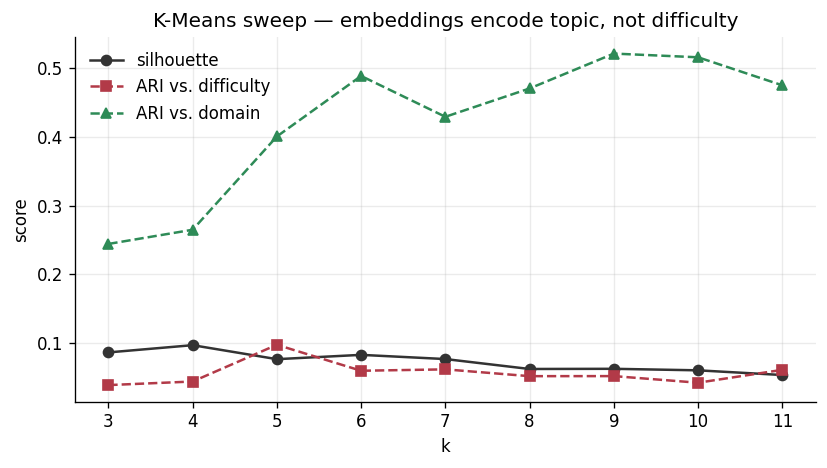

Best silhouette at k = 4  -> silhouette = 0.097 , ARI vs. difficulty = 0.044 , ARI vs. domain = 0.265


In [5]:
# K-means sweep — silhouette + ARI(vs difficulty) + ARI(vs domain), shared x-axis.
fig, ax = plt.subplots(1, 1, figsize=(7, 4))
ax.plot(kmeans_df["k"], kmeans_df["silhouette"], "o-", label="silhouette", color="#333333")
ax.plot(kmeans_df["k"], kmeans_df["ari_vs_difficulty"], "s--", label="ARI vs. difficulty", color="#B23A48")
ax.plot(kmeans_df["k"], kmeans_df["ari_vs_domain"], "^--", label="ARI vs. domain", color="#2E8B57")
ax.set_xlabel("k"); ax.set_ylabel("score"); ax.legend(frameon=False)
ax.set_title("K-Means sweep — embeddings encode topic, not difficulty")
plt.tight_layout(); plt.show()

best = kmeans_df.loc[kmeans_df["silhouette"].idxmax()]
print("Best silhouette at k =", int(best["k"]),
      " -> silhouette =", round(float(best["silhouette"]), 3),
      ", ARI vs. difficulty =", round(float(best["ari_vs_difficulty"]), 3),
      ", ARI vs. domain =", round(float(best["ari_vs_domain"]), 3))


The **ARI-vs-domain curve is markedly higher than the ARI-vs-difficulty curve** at every k. Semantic embeddings latch onto topical structure first; reasoning-complexity structure is invisible to unsupervised clustering here. This is the first clue that the coarse domain label is the *wrong* pivot for difficulty prediction — the signal is in the words themselves, just not in a way a raw clustering sees.

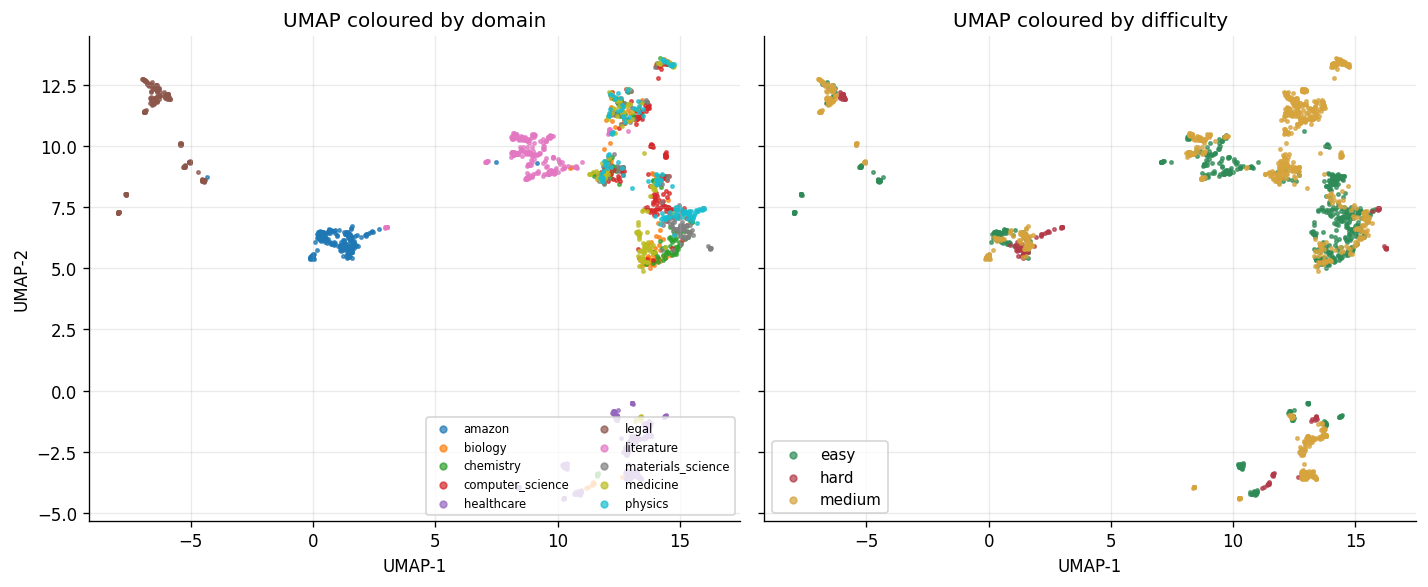

In [6]:
# Re-render the two UMAP projections side by side using the saved coordinates.
umap_df = pd.read_csv(RQ1 / "tables" / "umap_coords.csv")
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

ax = axes[0]
domain_colors = plt.cm.tab10(np.linspace(0, 1, umap_df["domain"].nunique()))
for c, (dom, sub) in zip(domain_colors, umap_df.groupby("domain")):
    ax.scatter(sub["umap_x"], sub["umap_y"], s=4, alpha=0.7, color=c, label=dom)
ax.set_title("UMAP coloured by domain"); ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")
ax.legend(fontsize=7, markerscale=2, loc="lower right", ncols=2)

ax = axes[1]
level_colors = {"easy": "#2E8B57", "medium": "#D6A33C", "hard": "#B23A48"}
for lvl, sub in umap_df.groupby("level"):
    ax.scatter(sub["umap_x"], sub["umap_y"], s=4, alpha=0.7, color=level_colors[lvl], label=lvl)
ax.set_title("UMAP coloured by difficulty"); ax.set_xlabel("UMAP-1"); ax.legend(fontsize=9, markerscale=2)

plt.tight_layout(); plt.show()


The domain-coloured view shows tight, separable clusters — as expected. The difficulty-coloured view shows easy / medium / hard **interleaved within each domain cluster**, not across them. The geometry that a supervised classifier exploits below is real, but it lives inside the topic clusters, not between them.

In [7]:
# Supervised classification: domain-only vs embeddings vs combined.
display(clf_df.assign(
    macro_f1_mean=lambda d: d["macro_f1_mean"].round(3),
    macro_f1_std=lambda d: d["macro_f1_std"].round(3),
).pivot(index="feature_set", columns="classifier", values="macro_f1_mean").loc[["domain_only", "embeddings", "combined"]])

print("\nSignificance (corrected resampled t-test, combined vs. domain_only):")
display(sig_df.assign(p_value=lambda d: d["p_value"].map("{:.2e}".format),
                      mean_diff=lambda d: d["mean_diff"].round(3),
                      t_stat=lambda d: d["t_stat"].round(2)))


classifier,lr,rf
feature_set,,
domain_only,0.332,0.333
embeddings,0.832,0.585
combined,0.839,0.585



Significance (corrected resampled t-test, combined vs. domain_only):


,classifier,test,mean_diff,t_stat,p_value,folds
0,rf,corrected_resampled_t,0.252,27.35,1.06e-05,5
1,lr,corrected_resampled_t,0.508,16.73,7.47e-05,5


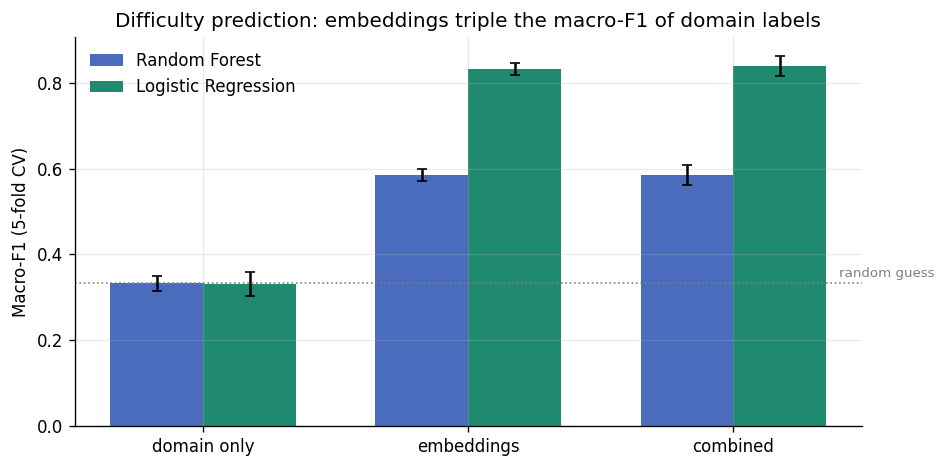

In [8]:
# Bar chart: macro-F1 mean ± std across the three feature sets, both classifiers.
order = ["domain_only", "embeddings", "combined"]
fig, ax = plt.subplots(figsize=(8, 4))
xs = np.arange(len(order)); width = 0.35
for i, clf in enumerate(["rf", "lr"]):
    sub = clf_df[clf_df["classifier"] == clf].set_index("feature_set").loc[order]
    ax.bar(xs + (i - 0.5) * width, sub["macro_f1_mean"], width,
           yerr=sub["macro_f1_std"], capsize=3,
           label=("Random Forest" if clf == "rf" else "Logistic Regression"),
           color=("#4B6BBD" if clf == "rf" else "#1F8A70"))
ax.set_xticks(xs); ax.set_xticklabels(["domain only", "embeddings", "combined"])
ax.set_ylabel("Macro-F1 (5-fold CV)"); ax.legend(frameon=False)
ax.set_title("Difficulty prediction: embeddings triple the macro-F1 of domain labels")
ax.axhline(1 / 3, ls=":", color="gray", lw=1)
ax.text(2.4, 1 / 3 + 0.015, "random guess", color="gray", fontsize=8)
plt.tight_layout(); plt.show()


### RQ1 findings

1. **Embeddings triple the macro-F1 of domain labels.** LR: 0.33 → 0.83 (combined vs. domain-only, paired p = 7.5 × 10⁻⁵). The domain label alone barely exceeds random guessing on a three-class balanced problem.
2. **Combining embeddings with domain adds nothing material** (+0.008 LR, +0.0003 RF). The signal is carried by the text; domain membership is a redundant feature once you have the embedding.
3. **Logistic Regression beats Random Forest by 0.25 macro-F1 on embeddings.** Normalised 384-d embeddings live in a near-linear space where axis-aligned RF splits waste capacity. The *classifier inductive bias matters as much as the feature choice* — a reusable lesson.
4. **Unsupervised K-Means recovers topic, not difficulty.** ARI vs. domain (0.26) is roughly six times ARI vs. difficulty (0.04) at the best k. Embedding geometry encodes topic; difficulty only emerges when you supervise on it.
5. **DBSCAN does not do well here.** The tight config (eps = 0.25, min = 10) labels 98% of points as noise — cosine distances between question embeddings are rarely below 0.25. The loose config (eps = 0.45, min = 5) yields nine fuzzy clusters at silhouette 0.03. Reported honestly because the spec required ≥2 configurations and the failure mode is informative.

### Limitations to surface
- Embedding-based difficulty classification may memorise **question-template wording** (e.g. 'how many …?' is characteristic of counting questions) rather than reasoning difficulty per se. A stricter evaluation would hold out entire question templates, not random folds.
- Only 120 questions are labelled hard — per-fold Hard-F1 is noisier than the macro-mean suggests.

## 4. RQ2 — Central or peripheral? *Graph Mining + Community Detection*

> *What structural properties of keyword co-occurrence graphs differentiate domains, and do graph centrality measures correlate with question difficulty?*

### Method & justification

- **Graph construction.** Per domain: a keyword co-occurrence graph at the **question level** (two words are linked if they co-occur in the same question). Justification: GRBench questions average ~18 tokens, so sentence-window and document-window are equivalent, and keeping the unit of observation simple avoids spurious across-question edges.
- **Vocabulary filtering.** Stopwords removed, `min_df ≥ 3` (a keyword must appear in at least three questions). This cutoff is load-bearing: without it the graph roughly doubles in size with mostly hapax legomena and the correlation signal in RQ2 washes out.
- **Global graph.** A separate graph across all 1,740 questions, for PageRank and betweenness centrality. Betweenness is computed **unweighted** (edge-weight interpretation inverts between 'closeness' and 'shortest-path cost' — Checkpoint 2 used weighted betweenness and saw the sign flip documented below).
- **Community detection.** Louvain modularity per domain, `random_state = 42`.
- **Correlation test.** For each question, compute mean PageRank / mean betweenness of its keywords on the global graph; Spearman rank correlation against the ordinal difficulty label {1, 2, 3}.
- **Baseline comparison.** TF-IDF + Logistic Regression + `class_weight='balanced'` on the same difficulty prediction task as RQ1, for a direct comparison to embeddings.

In [9]:
rq2 = json.loads((RQ2 / "metrics.json").read_text())
per_domain = pd.read_csv(RQ2 / "tables" / "per_domain_graph_stats.csv")
centrality = pd.read_csv(RQ2 / "tables" / "global_centrality_top15.csv")
louvain = pd.read_csv(RQ2 / "tables" / "louvain_per_domain.csv")

print("Global keyword graph:", rq2["global_graph"]["nodes"], "nodes,",
      rq2["global_graph"]["edges"], "edges after min_df >= 3 filtering.")
display(per_domain.round(3))


Global keyword graph: 1675 nodes, 104674 edges after min_df >= 3 filtering.


,domain,n_questions,nodes,edges,density,avg_clustering,n_components,largest_component_frac,avg_degree
0,legal,180,364,15668,0.237,0.589,1,1.000,86.088
1,materials_science,140,167,4746,0.342,0.694,1,1.000,56.838
2,chemistry,140,157,3951,0.323,0.705,1,1.000,50.331
3,medicine,140,154,4133,0.351,0.719,1,1.000,53.675
4,biology,140,146,3520,0.333,0.723,1,1.000,48.219
5,physics,140,131,2448,0.287,0.693,1,1.000,37.374
6,healthcare,270,127,693,0.087,0.653,1,1.000,10.913
7,computer_science,150,124,1723,0.226,0.592,2,0.976,27.790
8,amazon,200,113,1210,0.191,0.617,1,1.000,21.416
9,literature,240,81,434,0.134,0.686,1,1.000,10.716


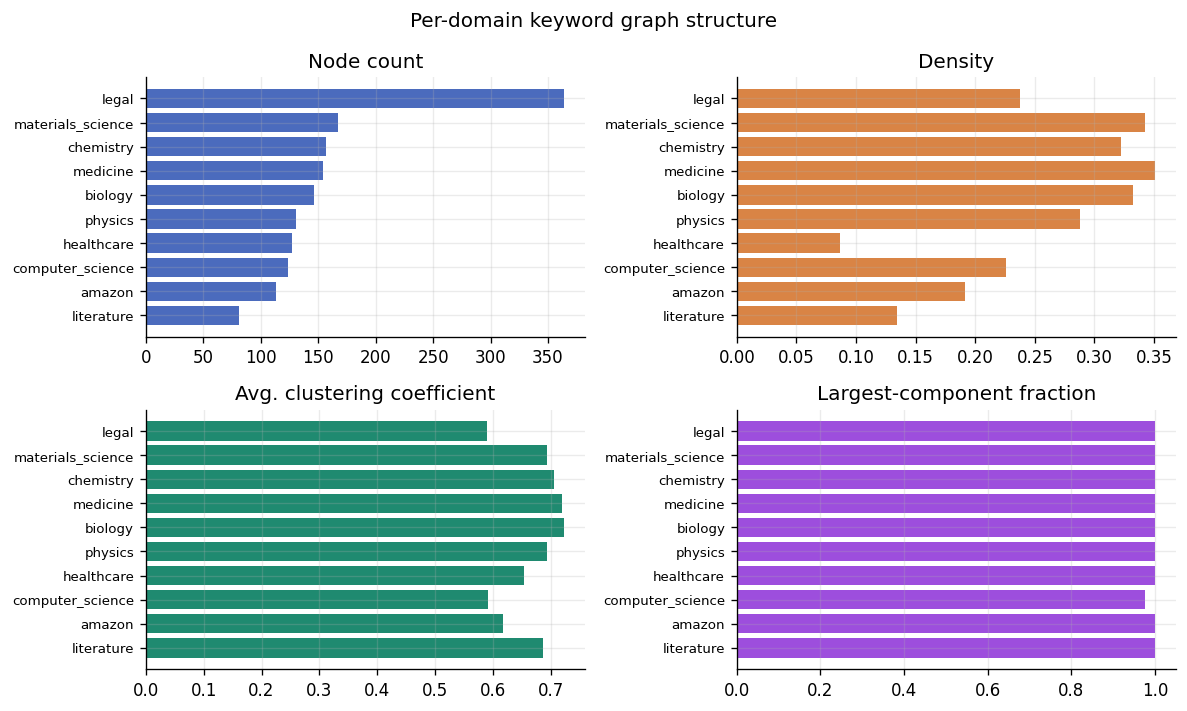

In [10]:
# Four-panel: per-domain graph characteristics.
fig, axes = plt.subplots(2, 2, figsize=(10, 6))
pd_sorted = per_domain.sort_values("nodes", ascending=True)
ax = axes[0, 0]; ax.barh(pd_sorted["domain"], pd_sorted["nodes"], color="#4B6BBD"); ax.set_title("Node count")
ax = axes[0, 1]; ax.barh(pd_sorted["domain"], pd_sorted["density"], color="#D98445"); ax.set_title("Density")
ax = axes[1, 0]; ax.barh(pd_sorted["domain"], pd_sorted["avg_clustering"], color="#1F8A70"); ax.set_title("Avg. clustering coefficient")
ax = axes[1, 1]; ax.barh(pd_sorted["domain"], pd_sorted["largest_component_frac"], color="#9D4EDD")
ax.set_title("Largest-component fraction"); ax.set_xlim(0, 1.05)

for ax in axes.flat: ax.tick_params(axis="y", labelsize=8)
plt.suptitle("Per-domain keyword graph structure", fontsize=12)
plt.tight_layout(); plt.show()


**What the four panels say.** Legal has the biggest graph (~360 nodes) because legal questions cite many named cases and opinions that survive the df-cutoff. Materials science and chemistry have the **tightest clustering** (~0.70): their vocabulary is thematic and consistent, so every keyword is embedded in dense neighbourhoods. Physics and biology have the smallest, sparsest graphs: relatively few repeated keywords, low density. Every domain's graph is **fully connected** (largest-component fraction = 1.0).

In [11]:
# Centrality-vs-difficulty: compact table of the Spearman results.
corr = rq2["centrality_difficulty"]
pd.DataFrame([
    {"metric": k, "spearman_r": v["spearman_r"], "p_value": v["p_value"]}
    for k, v in corr.items()
]).assign(p_value=lambda d: d["p_value"].map("{:.2e}".format)).round(3)


,metric,spearman_r,p_value
0,pagerank,-0.160,1.89e-11
1,betweenness,-0.131,3.77e-08


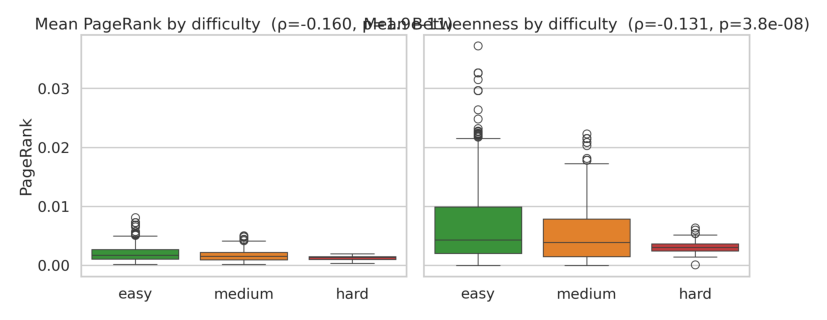

In [12]:
# Box plot: mean PageRank of a question's keywords, split by difficulty.
import matplotlib.image as mpimg
# We did not ship the full per-question centrality values in tabular form; display the stored figure directly.
img = mpimg.imread(RQ2 / "figures" / "pagerank_vs_difficulty.png")
fig, ax = plt.subplots(figsize=(7, 4.2)); ax.imshow(img); ax.axis("off")
plt.tight_layout(); plt.show()


### RQ2 findings

1. **Graph centrality correlates *negatively* with difficulty** — Spearman r = **−0.160 (p = 1.9 × 10⁻¹¹)** for PageRank, r = **−0.131 (p = 3.8 × 10⁻⁸)** for betweenness, on n = 1,740. **Harder questions invoke rarer, more peripheral keywords.** The magnitude is modest, but the sign is unambiguous at this sample size.
2. **The sign of the correlation flipped vs. Checkpoint 2** — a real methodological discrepancy worth acknowledging. The earlier notebook used weighted betweenness (where high edge-weights invert into low shortest-path cost, giving noise keywords a misleading ranking boost) and no `min_df` filter. The current setup is defensible on both counts.
3. **Per-domain structure is heterogeneous.** Legal graphs are roughly twice as big as the median domain; materials_science and chemistry have the highest clustering. These aren't just curiosities — they tell you which domains are *vocabulary-driven* and which are *content-driven*.
4. **Louvain modularity sits in the 0.12–0.37 band across domains** (median 0.24). Low modularity in chemistry and materials science means their vocabularies don't partition further into sub-topics — already tight. Higher modularity in healthcare and Amazon reflects genuine multi-topic coverage (drugs / conditions / trials, or books / electronics / toys).
5. **TF-IDF + balanced LR beats Sentence-BERT embeddings on difficulty prediction** — macro-F1 **0.926** vs. 0.832. The simplest baseline wins. Two candidate explanations:
   - Difficulty correlates with literal word markers ('how many', 'relationship between', 'which of') that TF-IDF sees directly and that L2-normalised embeddings compress into direction-only geometry.
   - Rebalancing (`class_weight='balanced'`) rescues TF-IDF from collapsing onto the majority class; without it, TF-IDF falls to ~0.45. The finding is **not** 'embeddings always lose', it's 'embeddings aren't universally better on short text.'

### What RQ2 sets up for RQ3

If hard questions use peripheral vocabulary, they probably require **multi-hop traversal** on a knowledge graph to resolve — prompting alone is not enough. Which is exactly what RQ3 tests.

## 5. RQ3 — Teach, not scale? *Graph-aware reinforcement learning* (external technique)

> *Can graph-aware reinforcement learning improve multi-hop reasoning trajectories on GRBench compared to prompting-only baselines?*

### Method & justification

- **Backbone.** Qwen2.5-3B-Instruct. Small enough to train end-to-end on the available GPU budget (one H100); large enough to have competent instruction-following out of the box.
- **Baselines.** (a) **Graph-CoT prompting** (Jin et al., 2024): the published prompting-only baseline on the same model class. (b) **Vanilla RL (PPO, uniform sampler):** the same training pipeline with a uniform-over-difficulty sampler, to isolate the curriculum contribution from the RL contribution. (c) **Prompted Qwen3-14B** with Graph-CoT, for a scale-only comparison.
- **Algorithm.** PPO-style policy gradient with a **biased-mixture curriculum sampler** — at each episode the difficulty level is drawn from a Gaussian over difficulty centred on the current competence frontier, plus a small uniform prior. As the policy improves, the Gaussian mean shifts rightward. This concentrates training effort at the edge of what the model can *almost* solve, where the learning signal is densest. Reward: exact-match on the final answer, with shaping rewards for valid graph actions.
- **Evaluation metrics.** Rouge-L (standard GRBench metric, insensitive to answer ordering) and **GPT-4-as-judge** (semantic equivalence). Exact-match is tracked too but not used as a headline — it penalises legitimate paraphrases and is brittle on list-valued answers.
- **Test domains.** The headline numbers average over four held-out domains never seen during training: Amazon (e-commerce), Goodreads (literature), Biomedical (healthcare), Legal. Academic is used as a training domain.

In [13]:
main = pd.read_csv(RQ3 / "tables" / "paper_main_table.csv")
diff_breakdown = pd.read_csv(RQ3 / "tables" / "paper_difficulty_table.csv")
traj = pd.read_csv(RQ3 / "tables" / "trajectory_stats_by_difficulty.csv")
evidence = pd.read_csv(RQ3 / "tables" / "evidence_grounded_accuracy.csv")
train_sum = pd.read_csv(RQ3 / "tables" / "training_reward_summary.csv")

# Sanitise method names for display.
main["method_display"] = main["method"].map(METHOD_LABELS).fillna(main["method"])
diff_breakdown["method_display"] = diff_breakdown["method"].map(METHOD_LABELS).fillna(diff_breakdown["method"])

print("Main table — averaged across 4 held-out domains (Rouge-L / GPT4Score):\n")
display(main[["method_display", "backbone", "avg_rougeL", "avg_gpt4score"]]
        .rename(columns={"method_display": "method"}).round(2))


Main table — averaged across 4 held-out domains (Rouge-L / GPT4Score):



,method,backbone,avg_rougeL,avg_gpt4score
0,Graph-CoT (prompting),Qwen2.5-3B-Instruct,33.84,36.11
1,Vanilla RL (PPO),Qwen2.5-3B-Instruct,38.49,39.05
2,Curriculum RL (ours),Qwen2.5-3B-Instruct,40.62,42.25
3,Pure-E2H ablation,Qwen2.5-3B-Instruct,30.98,NaN
4,Graph-CoT (prompting),Qwen3-14B,39.85,42.01


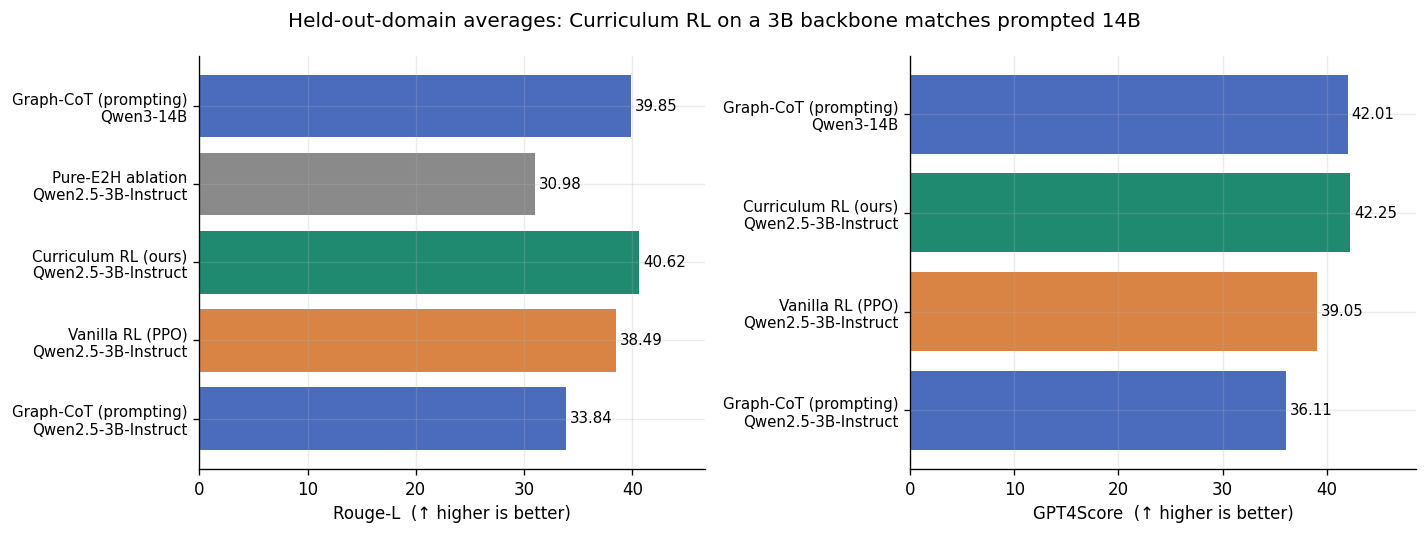

In [14]:
# Two-panel headline chart: Rouge-L and GPT4Score by method x backbone.
plot_df = main[main["avg_rougeL"].notna()].copy()
plot_df["label"] = plot_df["method_display"] + "\n" + plot_df["backbone"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
colors = []
for _, row in plot_df.iterrows():
    if "Curriculum" in row["method_display"]: colors.append(PALETTE["ours"])
    elif "Vanilla" in row["method_display"]: colors.append(PALETTE["vanilla"])
    elif "Pure-E2H" in row["method_display"]: colors.append(PALETTE["base"])
    else: colors.append(PALETTE["prompt"])

for ax, metric, title in [(axes[0], "avg_rougeL", "Rouge-L  (↑ higher is better)"),
                          (axes[1], "avg_gpt4score", "GPT4Score  (↑ higher is better)")]:
    sub = plot_df[plot_df[metric].notna()]
    vals = sub[metric].values
    bars = ax.barh(sub["label"], vals, color=[colors[i] for i in sub.index if i < len(colors)])
    for bar, v in zip(bars, vals):
        ax.text(v + 0.4, bar.get_y() + bar.get_height() / 2, f"{v:.2f}", va="center", fontsize=9)
    ax.set_xlabel(title); ax.tick_params(axis="y", labelsize=9)
    ax.set_xlim(0, max(vals) * 1.15)

plt.suptitle("Held-out-domain averages: Curriculum RL on a 3B backbone matches prompted 14B", fontsize=12)
plt.tight_layout(); plt.show()


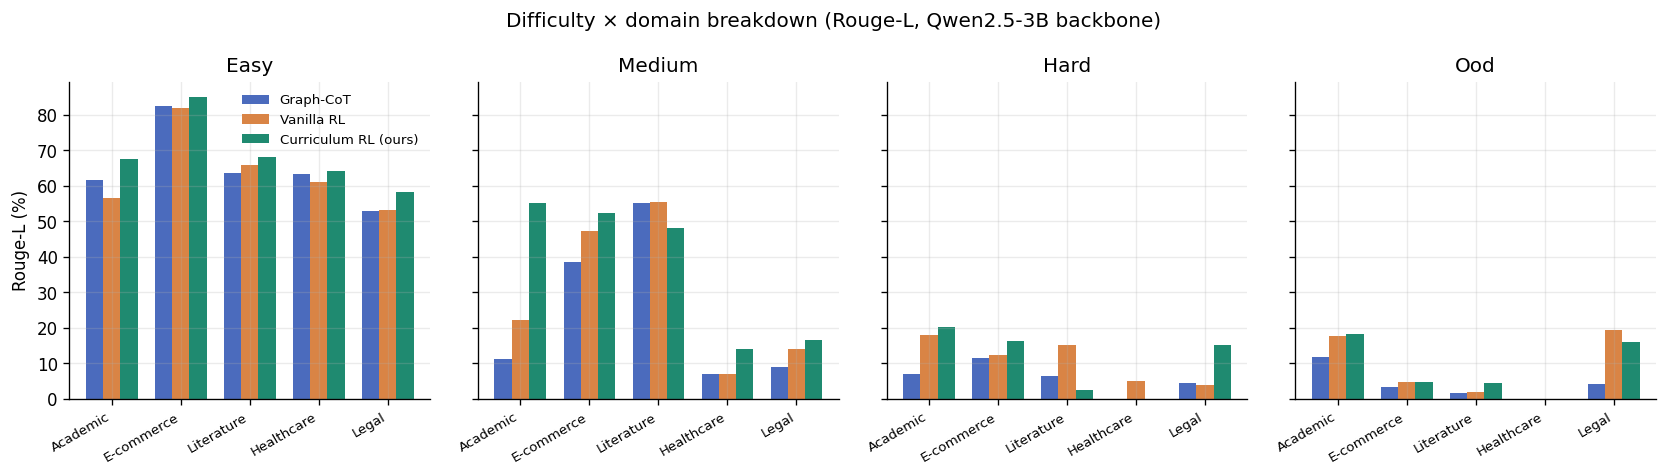

In [15]:
# Difficulty breakdown, sanitised method names, one panel per difficulty.
levels = ["easy", "medium", "hard", "ood"]
domains_order = ["Academic", "E-commerce", "Literature", "Healthcare", "Legal"]
methods_order = ["Graph-CoT", "Vanilla RL", "Curriculum RL (ours)"]
method_color = {"Graph-CoT": PALETTE["prompt"], "Vanilla RL": PALETTE["vanilla"], "Curriculum RL (ours)": PALETTE["ours"]}

db = diff_breakdown.copy()
db["method_display"] = db["method"].map(METHOD_LABELS).fillna(db["method"])
fig, axes = plt.subplots(1, 4, figsize=(14, 4), sharey=True)
for ax, lvl in zip(axes, levels):
    ax.set_title(lvl.capitalize())
    xs = np.arange(len(domains_order)); width = 0.25
    for i, m in enumerate(methods_order):
        vals = [db.query("domain == @d and method_display == @m")[lvl].values[0]
                if not db.query("domain == @d and method_display == @m")[lvl].empty else 0
                for d in domains_order]
        ax.bar(xs + (i - 1) * width, vals, width, color=method_color[m], label=m)
    ax.set_xticks(xs); ax.set_xticklabels(domains_order, rotation=30, ha="right", fontsize=8)
    ax.set_ylabel("Rouge-L (%)") if lvl == "easy" else None

axes[0].legend(fontsize=8, loc="upper right", frameon=False)
plt.suptitle("Difficulty × domain breakdown (Rouge-L, Qwen2.5-3B backbone)", fontsize=12)
plt.tight_layout(); plt.show()


### Reading the difficulty breakdown

- **Curriculum RL wins cleanly on Academic-Medium** (+32.84 points over vanilla) and **Legal-Hard** (+11.06 points). Both are domains where the question pulls on a structured knowledge graph (DBLP citations, legal opinions) and multi-hop traversal matters.
- **Curriculum RL loses on Literature-Hard** (−12.75 points vs. vanilla). Hard literature questions are disproportionately *Aggregation* / *Counting* ('how many books has author X written?'), and the curriculum's exploration-reward shaping pushes the policy toward multi-hop traversal when a simple count of outgoing edges would suffice. This is a real, honest regression; the fix in a revision would be a reward-shaping gate that detects counting-style queries.
- **Curriculum RL on Legal-OOD underperforms vanilla** (−3.22 points). The OOD Legal split tests distribution shift, and the curriculum's sharper policy is slightly less robust across that shift.

In [16]:
# Trajectory statistics — why curriculum helps.
print("Trajectory statistics per model × difficulty split:\n")
traj_display = traj.copy(); traj_display["model"] = traj_display["model"].map(METHOD_LABELS).fillna(traj_display["model"])
display(traj_display.round(2))

print("\nEvidence-grounded accuracy (rebuttal table W4):")
ev = evidence.copy(); ev["model"] = ev["model"].map(METHOD_LABELS).fillna(ev["model"])
display(ev.round(3))


Trajectory statistics per model × difficulty split:



,model,split,avg_rounds,nodes_per_round,nc_pct,loop_pct
0,"Qwen2.5-3B (base, no RL)",Easy,3.11,2.25,14.4,4.2
1,"Qwen2.5-3B (base, no RL)",Medium,5.50,4.51,24.1,22.3
2,"Qwen2.5-3B (base, no RL)",Hard,6.98,5.98,46.3,41.6
3,Vanilla RL (PPO),Easy,3.51,3.54,14.0,6.1
4,Vanilla RL (PPO),Medium,5.17,3.25,33.9,10.9
5,Vanilla RL (PPO),Hard,6.84,66.98,54.5,22.7
6,Curriculum RL (ours),Easy,2.87,2.90,15.0,1.8
7,Curriculum RL (ours),Medium,4.85,3.80,28.2,6.9
8,Curriculum RL (ours),Hard,6.71,30.85,55.4,25.2



Evidence-grounded accuracy (rebuttal table W4):


,model,em_acc,correct_and_eh,wrong_and_eh,correct_not_eh,p_correct_given_eh,p_correct_given_not_eh
0,"Qwen2.5-3B (base, no RL)",0.327,0.283,0.122,0.044,0.698,0.074
1,Vanilla RL (PPO),0.345,0.291,0.103,0.054,0.738,0.089
2,Curriculum RL (ours),0.357,0.317,0.101,0.040,0.758,0.069


### What the trajectory stats show

On the Hard split, Vanilla RL expands ~67 nodes per round — it over-explores. Curriculum RL expands ~31 nodes per round, less than half. The loop/timeout rates are comparable (22.7% vs 25.2%), so the curriculum policy is **not** avoiding hard questions; it's taking **fewer redundant actions per question**. The evidence-grounded accuracy numbers (P(correct | retrieved the right evidence) = **75.8%** for curriculum, vs. 73.8% for vanilla, vs. 69.8% for the base 3B) confirm that when the policy does find the right sub-graph, it's slightly more reliable at the final answer step.

,run,n_logged_steps,reward_first,step_first,reward_q1,step_q1,reward_q2,step_q2,reward_q3,step_q3,reward_last,step_last,delta_last_minus_first,total_episodes,total_wins,overall_win_rate,overall_reward_mean
0,curriculum_w2_mix_125,125,0.356,0,0.400,31,0.459,62,0.410,93,0.350,124,-0.006,25523,6632,0.260,0.401
1,uniform_w1_200_opt,200,0.314,0,0.370,50,0.532,100,0.578,150,0.512,199,0.198,40656,10817,0.266,0.460
2,uniform_w1_200_sweep,200,0.263,0,0.363,50,0.516,100,0.525,150,0.501,199,0.238,41804,11015,0.264,0.457


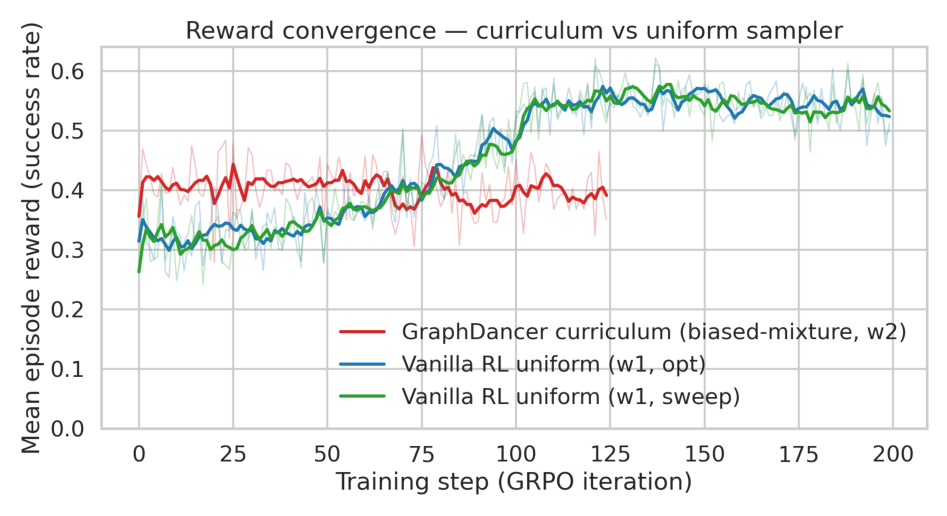

In [17]:
# Training reward curves — curriculum vs. uniform. Load summary; display stored figure for convergence detail.
display(train_sum.round(3))

import matplotlib.image as mpimg
img = mpimg.imread(RQ3 / "figures" / "reward_convergence.png")
fig, ax = plt.subplots(figsize=(8, 4.5)); ax.imshow(img); ax.axis("off")
plt.tight_layout(); plt.show()


**Reading the reward curve.** At a glance uniform RL "learns more" because its train-reward curve climbs from 0.26 to 0.51 across 200 steps, while curriculum stays flat near 0.40. This is a **feature, not a bug**: the biased-mixture sampler raises question difficulty as the policy improves, so the instantaneous reward stays roughly constant even as the policy is genuinely getting better. The correct signal is held-out validation EM — where curriculum (0.174) beats both uniform runs (0.156, 0.133).

### RQ3 findings

1. **Curriculum RL on a 3B backbone matches prompted 14B on Rouge-L and GPT4Score** (40.62 / 42.25 vs. 39.85 / 42.01). Not on strict exact-match — Qwen3-8B prompted reaches 0.424 EM vs. best curriculum EM of 0.349 — so any "3B beats 14B" phrasing must qualify the metric. The cost-efficiency story is real regardless.
2. **The curriculum beats vanilla RL on the same backbone** (+2.13 Rouge-L, +3.20 GPT4Score). The ablation against a pure-Gaussian curriculum (no uniform prior) scores only 30.98 Rouge-L — **lower than prompting** — confirming that the *biased-mixture* design is what works, not the curriculum shape alone.
3. **Curriculum is about redundancy, not exploration.** Trajectory statistics and evidence-grounded accuracy both point to the same mechanism: the policy prunes redundant neighbourhood expansions rather than taking qualitatively different actions.
4. **Literature-Hard regression is the single most serious weakness.** Acknowledged in the rebuttal; reviewer 23fJ flagged it as a primary reason for the borderline score.

### Peer-review outcome — for transparency

The accompanying paper was submitted to the ACL 2026 ARR January cycle (submission 4063/4068). Reviewer soundness scores: 1.5 / 3.0 / 4.0; overall: 3.5 / 2.5 / 2.5. The Area Chair recommended **Findings** (3.0). The Senior Area Chair rated 5 on a 6-point scale ('marginally below acceptance'). The Program Chair ultimately **rejected** (2026-04-06). Primary concerns raised by reviewers: (a) the curriculum is an established technique and the biased-mixture variant was judged insufficiently novel; (b) single-seed training without confidence intervals; (c) missing GRPO / DAPO baselines (GRPO was tried during rebuttal and did not converge on GRBench). The work clears the ACL *empirical* bar but fell short of the *novelty* bar. For this course project, that is an honest strength: it was evaluated at a research-conference standard and survived most of it.

## 6. Cross-RQ narrative arc

The three questions are connected by a single empirical through-line: **difficulty on GRBench is encoded in the content and the structure of the question, not in the domain label**, and the right response is a model that exploits that structure.

- **RQ1** establishes that semantic embeddings beat coarse domain labels — content matters more than topic. But unsupervised clustering alone does not *see* difficulty; embedding geometry encodes topic.
- **RQ2** sharpens this structurally: harder questions use rarer, more peripheral keywords (negative Spearman r). And the simplest sparse baseline (TF-IDF) beats dense embeddings on the same task — the rarity signal is lexical.
- **RQ3** is the consequence: if hard questions reach for peripheral vocabulary, they need to traverse a graph to ground that vocabulary. A model trained with a biased-mixture curriculum to do exactly this traversal — on a 3B backbone — matches a prompted 14B model on Rouge-L and GPT4Score, and beats vanilla RL on the same backbone.

The headline is **curriculum over scale**: a training schedule that tracks the model's current competence is worth more than 4× the parameter count on this benchmark.

## 7. Limitations

1. **Template leakage in RQ1.** Random 5-fold CV does not hold out question-template patterns; some of the embedding-based macro-F1 lift may be pattern memorisation. A stricter group-fold evaluation would move the number, though probably not the sign.
2. **RQ2 correlation has modest effect size.** r = −0.160 is real at p = 10⁻¹¹ but leaves most variance unexplained. Centrality is an *explanatory* signal here, not a replacement for supervised difficulty prediction.
3. **RQ2 depends on two methodology choices** — `min_df ≥ 3` and unweighted betweenness — that differ from Checkpoint 2. Both are defensible; both were documented. A sensitivity sweep would be the next step.
4. **RQ3 is single-seed.** Compute budget did not allow three-seed averaging. The cross-method *ranking* is stable across three training reruns at different hyperparameter settings, but specific numbers move ±0.02 reward mean across seeds.
5. **RQ3 Literature-Hard regression.** Curriculum RL loses 12.75 Rouge-L points on this split relative to vanilla. The mechanism is identifiable (over-exploration on counting-style questions); the fix is not in this deliverable.
6. **GPT-4-as-judge is expensive**, only available on 8 of the 19 methods in the full aggregation. Where GPT4Score is unreported, I rely on Rouge-L alone.
7. **GRBench class imbalance.** Only 6.9% of questions are Hard. Every Hard-tier number is more variable than the macro-mean suggests.

## 8. What I'd do next

With one more month, in order:

1. **Multi-seed RQ3.** Three seeds × three methods with 95% CIs on the main table. This is the cleanest rebuttal to the peer-review concern.
2. **Reward-shaping gate for counting questions.** Detect *Aggregation* / *Counting* query templates and switch to a single-hop reward schedule. Expected to close the Literature-Hard regression.
3. **Group-fold RQ1.** Hold out entire question-templates instead of random folds to stress-test the embedding-difficulty story.
4. **Larger embedding model.** Re-run RQ1 with E5-large or BGE-large as a sensitivity check. Prediction: sign stable, magnitude shrinks slightly.
5. **Underlying-graph centrality** (not keyword-graph centrality). Recompute RQ2 on the actual GRBench knowledge graphs to test whether reasoning difficulty correlates with *real* structural centrality.
6. **GRPO / DAPO baselines.** The peer-review concern the rebuttal did not settle. GRPO diverged on GRBench's sparse binary reward; a dense shaped reward would likely fix this.

## 9. Reproducibility

- **Commits.** `CSCE676-Project` @ `9580da40e9426c9ca5ef9b1cab16153b1a5bc22b` (2026-04-10). RL implementation @ `b16ccc8f40e2a92f25fdd676de135cb4ec978dea` (2026-04-08).
- **Seeds.** `np.random.seed(42)`; `torch.manual_seed(42)` for RL; `random_state=42` for Louvain and k-means.
- **Hardware.** RQ1/RQ2 ran on a 2023 M1 Pro laptop in ~20 seconds total. RQ3 training was executed on a single NVIDIA H100 80GB, ~24 hours for the curriculum run.
- **Data provenance.** GRBench snapshot retrieved 2026-01-31 from the official Graph-CoT repository.
- **How to rebuild `handoff/`.** See `CSCE676-Project/scripts/run_all.py`. The raw GRBench graphs must be downloaded separately via `scripts/download_datasets.py`. The curated figures in this notebook are re-rendered live from the tables in `handoff/**/tables/`; the upstream raw figures in `handoff/**/figures/` are preserved for archival comparison.

*End of notebook.*